# Eğitim Dinamiği

90 eğitim çalıştırmasının (4 deney × 5 fold × birden fazla yapılandırma) yakınsama davranışlarının analizi.

**Ne üretir:**
- Dengeli yakınsama eğrisi (SwinT_stage3_fold4)
- Aşırı öğrenme eğrisi (R50_layer4_fold0)
- Fold değişkenliği kutu grafiği
- Deney özet tabloları (konsola)

**Bağımlılıklar:** MLflow (CPU). GPU veya checkpoint gerekmez — hızlı çalışır.

**Çıktı dizini:** `figures/training_dynamics/`


### 1.1 Kurulum

In [1]:
import sys
import re
import json
import warnings
from collections import defaultdict
from pathlib import Path

import mlflow
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

mlflow.set_tracking_uri(str(PROJECT_ROOT / "mlruns"))
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name("woodland-fss")

FIGURES_CURVES = PROJECT_ROOT / "figures" / "training_dynamics"
FIGURES_CURVES.mkdir(parents=True, exist_ok=True)

%matplotlib inline
plt.rcParams["figure.dpi"] = 150

print(f"MLflow: {mlflow.get_tracking_uri()}")
print(f"Figures (curves): {FIGURES_CURVES}")


/home/zehra/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow: /home/zehra/Desktop/woodland/mlruns
Figures (curves): /home/zehra/Desktop/woodland/figures/training_curves


### 1.2 Tüm Eğitim Çalıştırmalarını Çek (n = 90)

In [2]:
def classify(name):
    """Run adını deney/yapılandırma/fold'a ayrıştır."""
    m = re.match(
        r"ProtoNet_(\w+?)(?:_([A-Za-z0-9]+))?_(none|layer3|layer4|stage3|stage4)_fold(\d)_seed-42",
        name,
    )
    if not m:
        return None
    backbone, pre_token, uf, fold = m.group(1), m.group(2), m.group(3), int(m.group(4))
    pretrained = pre_token if pre_token else "ImageNetV1"

    if uf == "none" and pretrained == "ImageNetV1" and backbone in {
        "ResNet18", "ResNet34", "ResNet50", "ResNet101", "ResNet152",
        "Xception", "SwinT", "ViTB16"
    }:
        return {"experiment": "E1_backbone", "config": backbone,
                "fold": fold, "backbone": backbone, "pretrained": pretrained, "unfreeze": uf}
    if uf in {"layer3", "layer4"} and backbone in {"ResNet18", "ResNet50"} and pretrained == "ImageNetV1":
        return {"experiment": "E2_layer_unfreeze", "config": f"{backbone}_{uf}",
                "fold": fold, "backbone": backbone, "pretrained": pretrained, "unfreeze": uf}
    if uf in {"stage3", "stage4"} and backbone == "SwinT":
        return {"experiment": "E3_stage_unfreeze", "config": f"SwinT_{uf}",
                "fold": fold, "backbone": backbone, "pretrained": pretrained, "unfreeze": uf}
    if uf == "none" and backbone == "ResNet50" and pretrained in {
        "BigEarthNet", "Cityscapes", "MillionAID", "SeCo"
    }:
        return {"experiment": "E4_pretrained", "config": f"ResNet50_{pretrained}",
                "fold": fold, "backbone": backbone, "pretrained": pretrained, "unfreeze": uf}
    return None


def fetch_history(run_id, metric):
    hist = client.get_metric_history(run_id, metric)
    return np.array(sorted([(m.step, m.value) for m in hist])) if hist else np.empty((0, 2))


def scissor_divergence(tl, vl, window=10000):
    """Son `window` epizotta train_loss düşüyor ama val_loss yükseliyor mu?"""
    if len(tl) < 5 or len(vl) < 5:
        return False, 0.0, 0.0
    max_step = max(tl[-1, 0], vl[-1, 0])
    lo = max_step - window
    tl_w = tl[tl[:, 0] >= lo]
    vl_w = vl[vl[:, 0] >= lo]
    if len(tl_w) < 3 or len(vl_w) < 3:
        return False, 0.0, 0.0
    tslope = np.polyfit(tl_w[:, 0], tl_w[:, 1], 1)[0]
    vslope = np.polyfit(vl_w[:, 0], vl_w[:, 1], 1)[0]
    return (tslope < -1e-7 and vslope > 5e-7), tslope, vslope


# Tüm train runlarını çek (isim tekrarı varsa en yeniyi al)
all_runs = client.search_runs([exp.experiment_id], max_results=500)
train_runs = [r for r in all_runs if r.data.params.get("phase") == "train"]
by_name = defaultdict(list)
for r in train_runs:
    by_name[r.info.run_name].append(r)
latest_train = {n: max(rl, key=lambda x: x.info.start_time) for n, rl in by_name.items()}

rows = []
for name, r in latest_train.items():
    info = classify(name)
    if info is None:
        continue
    tl = fetch_history(r.info.run_id, "train_loss")
    vl = fetch_history(r.info.run_id, "val_loss")
    mi = fetch_history(r.info.run_id, "val_mIoU")
    if len(tl) == 0 or len(vl) == 0 or len(mi) == 0:
        continue

    best_idx = mi[:, 1].argmax()
    vl_min_idx = vl[:, 1].argmin()
    opens, tslope, vslope = scissor_divergence(tl, vl)

    rows.append({
        "name": name, "run_id": r.info.run_id, **info,
        "best_miou": float(mi[best_idx, 1]),
        "best_episode": int(mi[best_idx, 0]),
        "last_train_loss": float(tl[-1, 1]),
        "last_val_loss": float(vl[-1, 1]),
        "val_loss_min": float(vl[vl_min_idx, 1]),
        "val_loss_rise": float(vl[-1, 1] - vl[vl_min_idx, 1]),
        "scissor_open": opens,
    })

rows.sort(key=lambda r: (r["experiment"], r["config"], r["fold"]))
print(f"Çalıştırma sayısı: {len(rows)}")


Çalıştırma sayısı: 90


### 1.3 Deney Bazlı Özet

In [3]:
by_exp = defaultdict(list)
for r in rows:
    by_exp[r["experiment"]].append(r)

print(f"{'Deney':<22} {'n':>4} {'Makas':>8} {'Ort. En İyi mIoU':>18} "
      f"{'Ort. En İyi Ep':>16} {'Ort. ΔL_val':>14}")
print("-" * 85)
for exp_label, rs in sorted(by_exp.items()):
    n = len(rs)
    sn = sum(1 for r in rs if r["scissor_open"])
    m_miou = np.mean([r["best_miou"] for r in rs])
    m_ep = np.mean([r["best_episode"] for r in rs])
    m_rise = np.mean([r["val_loss_rise"] for r in rs])
    print(f"{exp_label:<22} {n:>4} {sn}/{n:<6} {m_miou:>18.4f} "
          f"{m_ep:>16.0f} {m_rise:>+14.4f}")


Deney                     n    Makas   Ort. En İyi mIoU   Ort. En İyi Ep    Ort. ΔL_val
-------------------------------------------------------------------------------------
E1_backbone              40 3/40                 0.4786             5825        +0.0234
E2_layer_unfreeze        20 3/20                 0.4548             6550        +0.0487
E3_stage_unfreeze        10 2/10                 0.4866             6000        +0.0277
E4_pretrained            20 1/20                 0.5058            11500        +0.0284


### 1.4 Yakınsama Eğrisi — Yardımcı Fonksiyon

Aşırı öğrenme tanısı için `train_loss` ve `val_loss` aynı eksende çizilir (her ikisi de Focal + 0.5·Dice formülünden hesaplandığı için doğrudan karşılaştırılabilir). Genelleştirme boşluğu iki eğri arasındaki fark, aşırı öğrenme tanısı ise $\Delta L_\text{val}$ = son val_loss − minimum val_loss.

In [27]:
def plot_loss_curve(run_name, save_name):
    """train_loss + val_loss aynı eksende. Türkçe ondalık, serif font, başlıksız.
    Annotasyon ve legend konumları makasın büyüklüğüne göre dinamik."""
    r = next((r for r in rows if r["name"] == run_name), None)
    if r is None:
        raise ValueError(f"Çalıştırma bulunamadı: {run_name}")

    tl = fetch_history(r["run_id"], "train_loss")
    vl = fetch_history(r["run_id"], "val_loss")
    mi = fetch_history(r["run_id"], "val_mIoU")

    import matplotlib.ticker as mticker
    with plt.rc_context({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
        "mathtext.fontset": "stix",
    }):
        fig, ax = plt.subplots(figsize=(8, 4.5))

        ax.plot(tl[:, 0], tl[:, 1], color="#c0392b", linewidth=1.8, label="Eğitim kaybı")
        ax.plot(vl[:, 0], vl[:, 1], color="#2c3e50", linewidth=1.8,
                marker="o", markersize=3, label="Doğrulama kaybı")

        best_ep = int(mi[mi[:, 1].argmax(), 0])
        best_miou = float(mi[:, 1].max())
        miou_str = f"{best_miou:.3f}".replace(".", ",")
        ax.axvline(best_ep, color="green", linestyle="--", alpha=0.7,
                   label=f"En iyi mIoU (ep={best_ep}, {miou_str})")

        vl_last = float(vl[-1, 1])
        vl_min = float(vl[:, 1].min())
        delta = vl_last - vl_min

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, p: f"{x:.3f}".replace(".", ",")
        ))

        # Annotasyon konumu: makasın genişliğine göre
        x_text = vl[-1, 0] * 0.72
        t_at_x = float(np.interp(x_text, tl[:, 0], tl[:, 1]))
        v_at_x = float(np.interp(x_text, vl[:, 0], vl[:, 1]))

        wide_scissor = abs(v_at_x - t_at_x) > 0.05

        if wide_scissor:
            # Geniş makas (aşırı öğrenme): val çizgisinin altında, üst orta bölge
            y_text = v_at_x - 0.08
            # Legend'ı orta-sağa koy — hem val üstünden uzak hem annotasyonun altında
            legend_kwargs = dict(loc="upper right", bbox_to_anchor=(1.0, 0.55))
        else:
            # Dar makas (dengeli): val altı, ylim genişlet
            y_text = v_at_x - 0.03
            ymin, ymax = ax.get_ylim()
            ax.set_ylim(ymin - 0.04, ymax)
            # Legend üst sağ
            legend_kwargs = dict(loc="upper right", bbox_to_anchor=(1.0, 0.88))

        delta_str = f"{delta:+.3f}".replace(".", "{,}")
        ax.annotate(f"$\\Delta L = {delta_str}$",
                    xy=(vl[-1, 0], vl_last),
                    xytext=(x_text, y_text),
                    fontsize=10, color="#2c3e50",
                    ha="center", va="center",
                    arrowprops=dict(arrowstyle="->", color="#2c3e50", lw=0.8))

        ax.set_xlabel("Epizot", fontsize=11)
        ax.set_ylabel("Kayıp (Focal + 0,5·Dice)", fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, framealpha=0.9, edgecolor="gray", **legend_kwargs)
        plt.tight_layout()

        path = FIGURES_CURVES / f"{save_name}.png"
        fig.savefig(path, dpi=300, bbox_inches="tight")
        delta_print = f"{delta:+.4f}".replace(".", ",")
        miou_print = f"{best_miou:.4f}".replace(".", ",")
        print(f"Kaydedildi: {path}  |  ΔL = {delta_print}  |  En iyi mIoU = {miou_print} @ {best_ep}")
        plt.show()


### 1.5 Dengeli Yakınsama Örneği: Swin-T + aşama3 + fold 4

En küçük $\Delta L_\text{val}$ değerine sahip çalıştırma. Eğitim ve doğrulama kayıpları uyumlu biçimde düşer, genelleştirme boşluğu eğitim boyunca küçük kalır.

Kaydedildi: /home/zehra/Desktop/woodland/figures/training_curves/balanced_swint_stage3_fold4.png  |  ΔL = +0,0101  |  En iyi mIoU = 0,5028 @ 26000


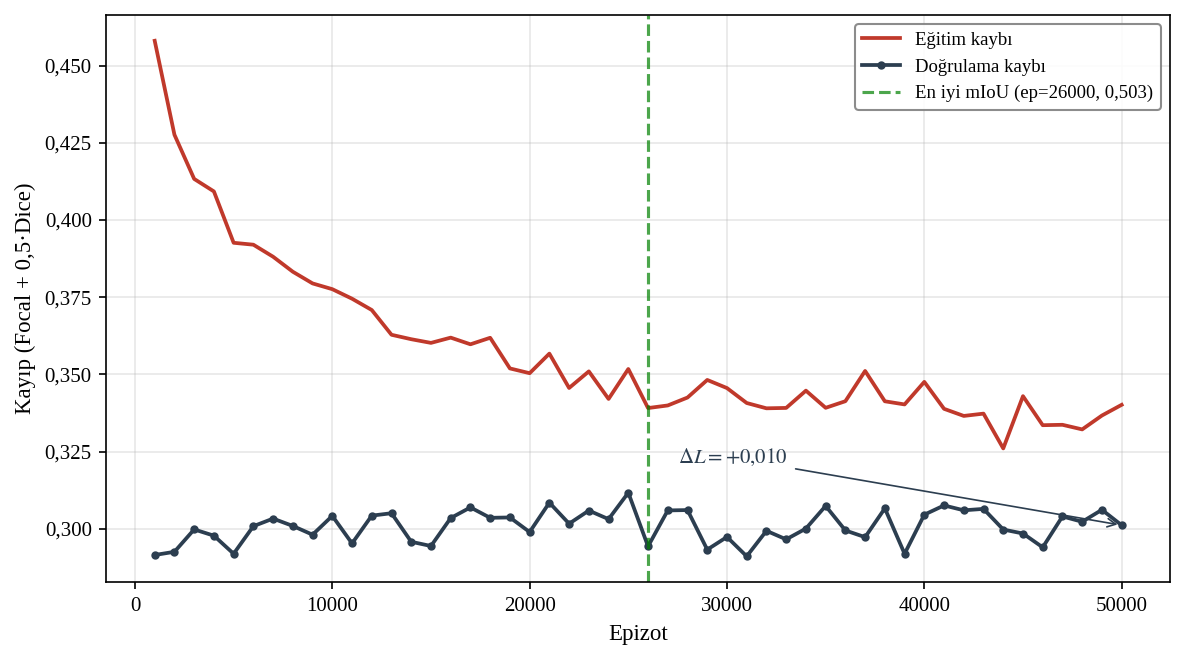

In [10]:
plot_loss_curve(
    run_name="ProtoNet_SwinT_ImageNetV1_stage3_fold4_seed-42",
    save_name="balanced_swint_stage3_fold4",
)


### 1.6 Aşırı Öğrenme Örneği: ResNet-50 + katman4 + fold 0

En yüksek $\Delta L_\text{val}$ değerlerinden biri ve eğitim son $10\,000$ epizotunda hâlâ makas açılmaya devam eden bir çalıştırma. Eğitim kaybı $0.163$'e düşerken doğrulama kaybı minimumundan $+0.122$ yükselir.

Kaydedildi: /home/zehra/Desktop/woodland/figures/training_curves/overfit_resnet50_layer4_fold0.png  |  ΔL = +0,1222  |  En iyi mIoU = 0,4087 @ 1000


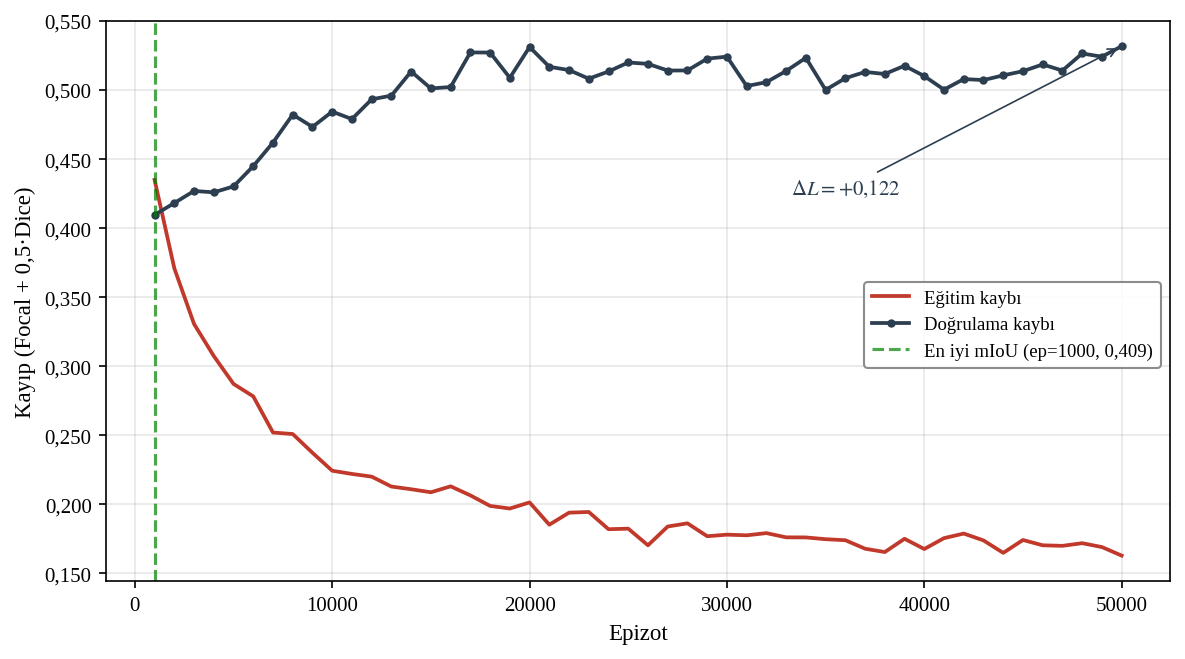

In [28]:
plot_loss_curve(
    run_name="ProtoNet_ResNet50_layer4_fold0_seed-42",
    save_name="overfit_resnet50_layer4_fold0",
)


### 1.7 Fold Bazlı Ağaçlık Oranı ve Test fgIoU Dağılımı

In [33]:
# Kfold splitleri & tile registry
with open(PROJECT_ROOT / "data/processed/image_level_split.json") as f:
    split_data = json.load(f)
with open(PROJECT_ROOT / "data/processed/tile_registry.json") as f:
    reg = json.load(f)

test_ortos_per_fold = {int(k.replace("fold_", "")): v["test"]
                       for k, v in split_data["kfold_splits"].items()}

# Tüm tileları tek dict'e birleştir
all_tiles = {}
for split_name, tiles in reg["splits"].items():
    for tid, tinfo in tiles.items():
        all_tiles[tid] = tinfo

# Her fold'un test ortofotolarındaki ağaçlık (sınıf 2) oranı
fold_woodland = {}
for f_i, ortos in test_ortos_per_fold.items():
    orto_set = set(ortos)
    wp, tp = 0, 0
    for tid, tinfo in all_tiles.items():
        if tinfo.get("source_image") in orto_set:
            cs = tinfo.get("class_stats", {})
            wp += cs.get("2", {}).get("pixel_count", 0)
            tp += sum(int(c.get("pixel_count", 0)) for c in cs.values())
    fold_woodland[f_i] = wp / tp if tp > 0 else 0

print("Fold bazlı ağaçlık piksel oranı (test ortofotolarında):")
for f_i in sorted(fold_woodland):
    print(f"  Fold {f_i}: {fold_woodland[f_i]:.4f} ({fold_woodland[f_i]*100:.1f}%)")


Fold bazlı ağaçlık piksel oranı (test ortofotolarında):
  Fold 0: 0.2474 (24.7%)
  Fold 1: 0.3977 (39.8%)
  Fold 2: 0.2995 (30.0%)
  Fold 3: 0.3608 (36.1%)
  Fold 4: 0.3578 (35.8%)


In [34]:
# Test runlarından test_fgIoU'ları çek
test_runs = [r for r in all_runs if r.data.params.get("phase") == "test"]
by_name_t = defaultdict(list)
for r in test_runs:
    by_name_t[r.info.run_name].append(r)
latest_test = {n: max(rl, key=lambda x: x.info.start_time) for n, rl in by_name_t.items()}


def parse_test(name):
    m = re.match(r"(?:TEST_)?ProtoNet_(\w+?)(?:_([A-Za-z0-9]+))?_(none|layer3|layer4|stage3|stage4)_fold(\d)_seed-42", name)
    if m:
        return int(m.group(4))
    return None


fold_fgiou = defaultdict(list)
for name, r in latest_test.items():
    fold = parse_test(name)
    fg = r.data.metrics.get("test_fgIoU")
    if fold is not None and fg is not None:
        fold_fgiou[fold].append(fg)

print("\nFold bazlı test fgIoU istatistikleri (18 yapılandırma):")
print(f"{'Fold':>4} {'n':>4} {'ort.':>8} {'std':>8} {'med.':>8} {'min':>8} {'max':>8}")
for f_i in sorted(fold_fgiou):
    a = np.array(fold_fgiou[f_i])
    print(f"{f_i:>4} {len(a):>4} {a.mean():>8.4f} {a.std():>8.4f} "
          f"{np.median(a):>8.4f} {a.min():>8.4f} {a.max():>8.4f}")



Fold bazlı test fgIoU istatistikleri (18 yapılandırma):
Fold    n     ort.      std     med.      min      max
   0   18   0.4526   0.0254   0.4559   0.3937   0.4893
   1   18   0.5800   0.0274   0.5817   0.5410   0.6559
   2   18   0.4253   0.0327   0.4156   0.3829   0.4859
   3   18   0.4948   0.0376   0.5007   0.4363   0.5511
   4   18   0.5268   0.0384   0.5277   0.4295   0.6214


### 1.8 Fold Değişkenliği — Kutu Grafiği

Kat 0: toplam 18 nokta — {'E1': 8, 'E2': 4, 'E3': 2, 'E4': 4}
Kat 1: toplam 18 nokta — {'E1': 8, 'E2': 4, 'E3': 2, 'E4': 4}
Kat 2: toplam 18 nokta — {'E1': 8, 'E2': 4, 'E3': 2, 'E4': 4}
Kat 3: toplam 18 nokta — {'E1': 8, 'E2': 4, 'E3': 2, 'E4': 4}
Kat 4: toplam 18 nokta — {'E1': 8, 'E2': 4, 'E3': 2, 'E4': 4}

Kaydedildi: /home/zehra/Desktop/woodland/figures/training_curves/fold_variance_boxplot.png


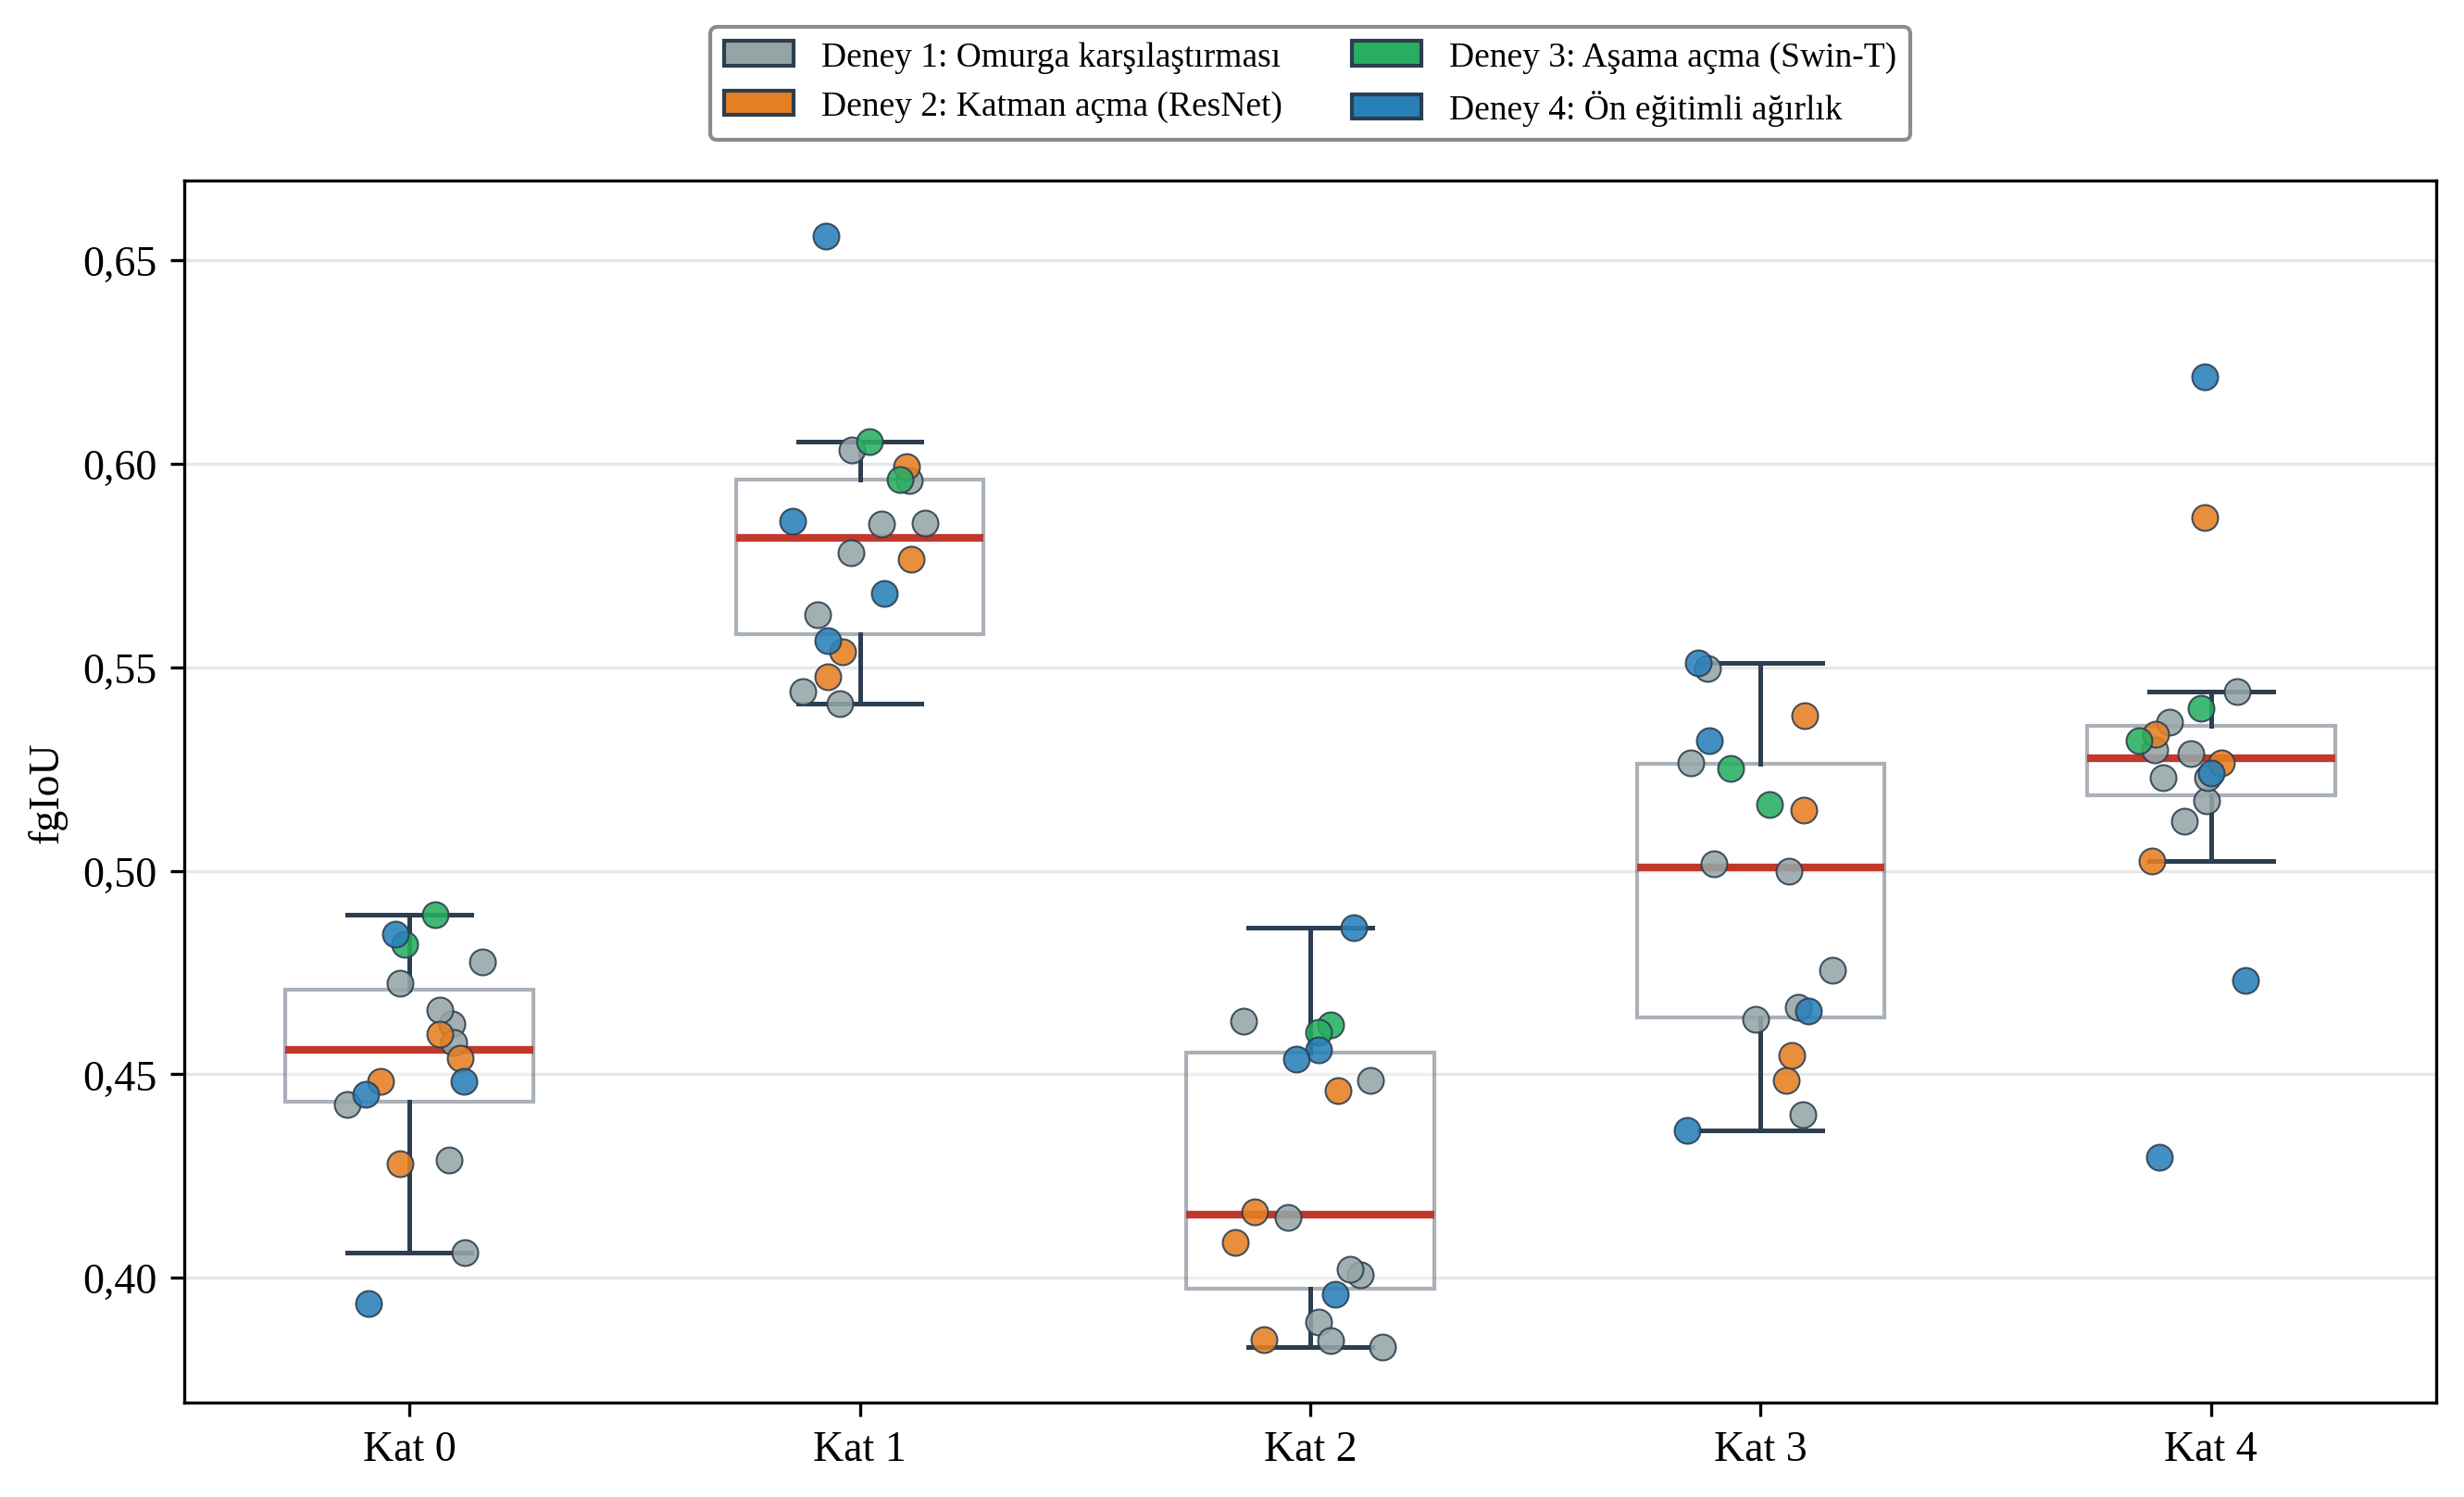

In [36]:
import re
import numpy as np
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

# --- Yapılandırmaları deneye sınıflandır ve fold başına fgIoU topla ---
def classify_ckey(backbone, pretrained, uf):
    if uf == "none" and pretrained in {"BigEarthNet", "Cityscapes", "MillionAID", "SeCo"}:
        return "E4"
    if uf in {"stage3", "stage4"}:
        return "E3"
    if uf in {"layer3", "layer4"}:
        return "E2"
    if uf == "none" and pretrained == "ImageNetV1":
        return "E1"
    return None


exp_fold_points = {exp: {f: [] for f in range(5)} for exp in ["E1", "E2", "E3", "E4"]}
for name, r in latest_test.items():
    m = re.match(r"(?:TEST_)?ProtoNet_(\w+?)(?:_([A-Za-z0-9]+))?_(none|layer3|layer4|stage3|stage4)_fold(\d)_seed-42", name)
    if not m:
        continue
    backbone = m.group(1)
    pretrained = m.group(2) or "ImageNetV1"
    uf = m.group(3)
    fold = int(m.group(4))
    exp_label = classify_ckey(backbone, pretrained, uf)
    fg = r.data.metrics.get("test_fgIoU")
    if exp_label and fg is not None:
        exp_fold_points[exp_label][fold].append(fg)

# Yapılandırma sayısı kontrolü (her katta 8+4+2+4=18 beklenir)
for f in range(5):
    total = sum(len(exp_fold_points[e][f]) for e in exp_fold_points)
    per_exp = {e: len(exp_fold_points[e][f]) for e in exp_fold_points}
    print(f"Kat {f}: toplam {total} nokta — {per_exp}")

# --- Renklendirme ve etiketler ---
EXP_COLORS = {
    "E1": "#95a5a6",  # gri — omurga
    "E2": "#e67e22",  # turuncu — katman açma
    "E3": "#27ae60",  # yeşil — aşama açma
    "E4": "#2980b9",  # mavi — ön eğitim
}
EXP_LABELS = {
    "E1": "Deney 1: Omurga karşılaştırması",
    "E2": "Deney 2: Katman açma (ResNet)",
    "E3": "Deney 3: Aşama açma (Swin-T)",
    "E4": "Deney 4: Ön eğitimli ağırlık",
}

with plt.rc_context({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 11,
}):
    fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)

    folds = sorted(fold_fgiou)

    # Kutu grafiği (arka plan, solgun — noktalar ön planda)
    data = [fold_fgiou[i] for i in folds]
    bp = ax.boxplot(
        data, positions=folds, widths=0.55, patch_artist=True,
        medianprops=dict(color="#c0392b", linewidth=2),
        boxprops=dict(facecolor="white", alpha=0.4, edgecolor="#2c3e50"),
        whiskerprops=dict(color="#2c3e50", linewidth=1.2),
        capprops=dict(color="#2c3e50", linewidth=1.2),
        showfliers=False,  # aykırı değerler zaten scatter'da görünecek
    )

    # Her yapılandırma noktası — deneye göre renkli, jitter ile
    rng = np.random.default_rng(42)
    for exp_label, color in EXP_COLORS.items():
        for fold in folds:
            values = exp_fold_points[exp_label][fold]
            if not values:
                continue
            x = rng.uniform(fold - 0.17, fold + 0.17, size=len(values))
            ax.scatter(x, values, c=color, s=45, alpha=0.88,
                       edgecolor="#2c3e50", linewidth=0.5, zorder=3)

    ax.set_xticks(folds)
    ax.set_xticklabels([f"Kat {i}" for i in folds])
    #ax.set_xlabel("Çapraz Doğrulama Katı", fontsize=11)
    ax.set_ylabel("fgIoU", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, p: f"{x:.2f}".replace(".", ",")
    ))
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_axisbelow(True)

    # Legend — grafiğin üstünde, 2 sütun
    legend_handles = [
        Patch(facecolor=color, edgecolor="#2c3e50", label=EXP_LABELS[exp])
        for exp, color in EXP_COLORS.items()
    ]
    ax.legend(handles=legend_handles, loc="upper center",
              bbox_to_anchor=(0.5, 1.14), ncol=2,
              fontsize=9, framealpha=0.9, edgecolor="gray")

    plt.tight_layout()
    path = FIGURES_CURVES / "fold_variance_boxplot.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"\nKaydedildi: {path}")
    plt.show()


### 1.9 Fold Sıralaması — Hangi fold kaç yapılandırmada en iyi/en kötü?

In [37]:
# Yapılandırma başına 5 fold test fgIoU
config_fold = defaultdict(dict)
for name, r in latest_test.items():
    m = re.match(r"(?:TEST_)?ProtoNet_(\w+?)(?:_([A-Za-z0-9]+))?_(none|layer3|layer4|stage3|stage4)_fold(\d)_seed-42", name)
    if not m:
        continue
    ckey = f"{m.group(1)}|{m.group(2) or 'ImageNetV1'}|{m.group(3)}"
    fg = r.data.metrics.get("test_fgIoU")
    if fg is not None:
        config_fold[ckey][int(m.group(4))] = fg

max_counts = defaultdict(int)
min_counts = defaultdict(int)
n_complete = 0
for ckey, folds in config_fold.items():
    if len(folds) == 5:
        n_complete += 1
        max_counts[max(folds, key=folds.get)] += 1
        min_counts[min(folds, key=folds.get)] += 1

print(f"Tam 5 foldlu yapılandırma: {n_complete}")
print(f"{'Fold':>4} {'En İyi':>8} {'%':>6} {'En Kötü':>8} {'%':>6}")
for f_i in range(5):
    print(f"{f_i:>4} {max_counts[f_i]:>8} {100*max_counts[f_i]/n_complete:>6.1f} "
          f"{min_counts[f_i]:>8} {100*min_counts[f_i]/n_complete:>6.1f}")


Tam 5 foldlu yapılandırma: 18
Fold   En İyi      %  En Kötü      %
   0        0    0.0        4   22.2
   1       17   94.4        0    0.0
   2        0    0.0       14   77.8
   3        0    0.0        0    0.0
   4        1    5.6        0    0.0


### 1.10 Yapılandırma Bazlı Eğitilebilir Parametre + Ortalama Test fgIoU

In [38]:
# Her yapılandırma için eğitilebilir parametre ve ortalama test fgIoU
config_trainable = {}
for name, r in latest_train.items():
    info = classify(name)
    if info is None:
        continue
    ckey = f"{info['backbone']}|{info['pretrained']}|{info['unfreeze']}"
    if ckey not in config_trainable:
        tp = r.data.params.get("trainable_params")
        config_trainable[ckey] = int(tp) if tp is not None else None

print(f"{'Yapılandırma':<42} {'Eğitilebilir':>14} {'Ort. fgIoU':>12} {'Std':>8}")
print("-" * 80)
for ckey in sorted(config_trainable):
    tr = config_trainable[ckey]
    vals = list(config_fold.get(ckey, {}).values())
    if tr is None or not vals:
        continue
    print(f"{ckey:<42} {tr:>14,d} {np.mean(vals):>12.4f} {np.std(vals):>8.4f}")


Yapılandırma                                 Eğitilebilir   Ort. fgIoU      Std
--------------------------------------------------------------------------------
ResNet101|ImageNetV1|none                         524,801       0.5019   0.0685
ResNet152|ImageNetV1|none                         524,801       0.4971   0.0677
ResNet18|ImageNetV1|layer3                     10,625,025       0.4773   0.0606
ResNet18|ImageNetV1|layer4                      8,525,313       0.4844   0.0495
ResNet18|ImageNetV1|none                          131,585       0.4978   0.0467
ResNet34|ImageNetV1|none                          131,585       0.4786   0.0707
ResNet50|BigEarthNet|none                         524,801       0.4533   0.0544
ResNet50|Cityscapes|none                          524,801       0.4851   0.0512
ResNet50|ImageNetV1|layer3                     22,587,905       0.5151   0.0660
ResNet50|ImageNetV1|layer4                     15,489,537       0.4889   0.0659
ResNet50|ImageNetV1|none               